# Class 8: Combined Vulnerability & Risk Assessment

**GIS Vulnerability & Risk Assessment Course**

## Learning Objectives

By the end of this notebook, you will:

1. **Understand the final integration** of Vulnerability and Risk scores into a single Combined Score
2. **Apply a decision matrix** to synthesize vulnerability and risk results
3. **Visualize the scoring matrix** to see how vulnerability and risk combine
4. **Create publication-quality maps** showing the final combined assessment
5. **Summarize results** across your study area
6. **Reflect on the full journey** from exposure → vulnerability → risk → combined assessment

## What We're Building

This is the **culminating notebook** of our GIS Vulnerability & Risk Assessment course. You've now completed a comprehensive analysis:

- **Class 1**: Exposure — What's at risk?
- **Class 2**: Potential Impact — What could be damaged?
- **Class 3**: Adaptive Capacity — How prepared are we?
- **Class 4**: Vulnerability — Combined Impact and Capacity
- **Class 5**: Probability — How likely is the hazard?
- **Class 6**: Consequence — How serious would the impact be?
- **Class 7**: Risk — Combined Probability and Consequence
- **Class 8** (today): **Combined Score** — The complete picture

Congratulations on reaching the final step!


## 1. Setup & Libraries

We'll use the same libraries as throughout the course. In Google Colab, we mount your Google Drive and install additional GIS packages.


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

# Define base directory
BASE_DIR = '/content/drive/MyDrive/MSER_510_VULNERABILTY'
DATA_DIR = os.path.join(BASE_DIR, 'data')

# GeoPackage file paths for chained loading
INPUT_GPKG = os.path.join(DATA_DIR, 'class_7_risk.gpkg')  # Load from Class 7
OUTPUT_GPKG = os.path.join(DATA_DIR, 'class_8_final.gpkg')  # Save to Class 8
CLASS0_GPKG = os.path.join(DATA_DIR, 'vulnerability_risk_data.gpkg')  # Fallback for base layers

print(f"Base directory: {BASE_DIR}")
print(f"Contents: {os.listdir(BASE_DIR)}")

### Optional: Run Locally Instead of Google Colab

If you prefer to run this notebook on your own machine (e.g., using Jupyter or VS Code) instead of Google Colab, comment out the Google Drive cell above and uncomment the cell below. Update the `BASE_DIR` path to point to a folder on your local filesystem.

In [ ]:
# LOCAL RUN: Uncomment the lines below to run locally instead of Google Colab
# Update the path to match your local folder

# import os

# BASE_DIR = './'
# DATA_DIR = os.path.join(BASE_DIR, 'data')
# OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')

# os.makedirs(DATA_DIR, exist_ok=True)
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# INPUT_GPKG = os.path.join(DATA_DIR, 'class_7_risk.gpkg')
# OUTPUT_GPKG = os.path.join(DATA_DIR, 'class_8_final.gpkg')
# CLASS0_GPKG = os.path.join(DATA_DIR, 'vulnerability_risk_data.gpkg')

In [3]:
# Install required packages
!pip install geopandas fiona shapely pyproj requests folium seaborn contextily --quiet

# Import libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap, Normalize
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
All libraries loaded successfully!


## 2. Load Data with Vulnerability & Risk Scores

We load the parcels layer from the GeoPackage. This layer should contain:
- **vulnerability**: Score from Class 4 (1=Low, 2=Medium, 3=High)
- **risk**: Score from Class 7 (1=Low, 2=Medium, 3=High)
- All other fields from previous classes (exposure, potential_impact, adaptive_capacity, probability, consequence)

If you haven't completed Classes 4 and 7 yet, those fields will be populated by running those notebooks first.


In [4]:
# Define path to GeoPackage (from Class 7)
gpkg_path = INPUT_GPKG

# Check if file exists
if os.path.exists(gpkg_path):
    print(f"✓ Found INPUT GeoPackage: {gpkg_path}")
else:
    print(f"✗ NOT FOUND: {gpkg_path}")
    print(f"   Make sure you've completed Classes 1-7 first!")

✓ Found INPUT GeoPackage: ./data/class_7_risk.gpkg


In [5]:
# Load parcels layer from INPUT GeoPackage (from Class 7)
parcels = gpd.read_file(gpkg_path, layer='parcels')

print(f"Loaded {len(parcels)} parcels from Class 7")
print(f"\nColumns available:")
print(parcels.columns.tolist())

# Show first few rows
print(f"\nFirst 5 parcels:")
parcels.head()

Loaded 16078 parcels from Class 7

Columns available:
['objectid', 'parno', 'altparno', 'ownname', 'improvval', 'landval', 'parval', 'mailadd', 'munit', 'mcity', 'mstate', 'mzip', 'siteadd', 'sunit', 'scity', 'gisacres', 'struct', 'multistruc', 'saledate', 'saledatetx', 'legdecfull', 'parusecode', 'parusedesc', 'parusecd2', 'parusedsc2', 'parvaltype', 'owntype', 'recareano', 'recareatx', 'revisedate', 'sourceref', 'sourcedate', 'sourcedatx', 'subdivisio', 'nparno', 'cntyname', 'cntyfips', 'stfips', 'stcntyfips', 'gnisid', 'sourceagnt', 'transfdate', 'maddpref', 'maddrno', 'maddstname', 'maddstr', 'maddstsuf', 'maddsttyp', 'ownfrst', 'ownlast', 'revdatetx', 'reviseyear', 'saddno', 'saddpref', 'saddstname', 'saddstr', 'saddstsuf', 'saddsttyp', 'sstate', 'stname', 'subowntype', 'subsurfown', 'szip', 'structno', 'structyear', 'ownname2', 'presentval', 'mapref', 'st_area(shape)', 'st_perimeter(shape)', 'FLD_ZONE', 'ZONE_SUBTY', 'exposure', 'is_community_asset', 'asset_group', 'building_expo

,objectid,parno,altparno,ownname,improvval,landval,parval,mailadd,munit,mcity,...,is_community_asset,asset_group,building_exposed,potential_impact,adaptive_capacity,vulnerability,probability,consequence,risk,geometry
0,24258999,965737309300000,965737309300000,MH MISSION HOSPITAL LLLP,41407600,8500000,49907600,PO BOX 80610,,INDIANAPOLIS,...,0,Other,0,0,3,0,0,0,0,"MULTIPOLYGON (((952839.126 677482.722, 952886...."
1,24238300,965727709500000,965727709500000,HOPEMONT ASSOCIATES LLC,1089900,1493900,2583800,17 POINT BLUFF DR,,ASHEVILLE,...,0,Other,0,1,2,1,2,3,3,"MULTIPOLYGON (((952578.59 677394.759, 952579.1..."
2,24306996,965727438200000,965727438200000,SMST 127 SWEETEN CREEK RD LLC,1685800,745200,2431000,10 TERRACE RD,,LADERA RANCH,...,0,Other,1,2,2,2,2,3,3,"MULTIPOLYGON (((952313.58 677418.69, 952257.71..."
3,24217313,965737261600000,965737261600000,92CRAYTON LLC,527800,250900,778700,277 MOFFITT BRANCH RD,,ASHEVILLE,...,1,Asset 2,0,0,3,0,1,0,0,"MULTIPOLYGON (((952923.611 677487.173, 952886...."
4,24289352,965728704200000,965728704200000,HARDY GARY V,0,20700,20700,PO BOX 30642,,CHARLESTON,...,0,Other,0,0,3,0,0,0,0,"MULTIPOLYGON (((952846.165 677977.109, 952623...."


In [6]:
# Check for required vulnerability and risk fields
required_fields = ['vulnerability', 'risk']
missing = [f for f in required_fields if f not in parcels.columns]

if missing:
    print(f"⚠ WARNING: Missing fields: {missing}")
    print("These will be created with default values for demonstration.")
    for field in missing:
        parcels[field] = 1  # Default to Low (1)
else:
    print(f"✓ All required fields present!")

# Display summary statistics
print(f"\nVulnerability Score Distribution:")
print(parcels['vulnerability'].value_counts().sort_index())
print(f"\nRisk Score Distribution:")
print(parcels['risk'].value_counts().sort_index())


✓ All required fields present!

Vulnerability Score Distribution:
vulnerability
0    13849
1     1328
2      258
3      643
Name: count, dtype: int64

Risk Score Distribution:
risk
0    13849
1      206
2      973
3     1050
Name: count, dtype: int64


## 3. Understanding the Combined Scoring Matrix

### How Vulnerability & Risk Come Together

In the previous classes, you learned:

- **Vulnerability (Class 4)**: Combines Potential Impact × Adaptive Capacity
  - High vulnerability = high impact + low adaptive capacity = more exposed to harm

- **Risk (Class 7)**: Combines Probability × Consequence
  - High risk = likely hazard + serious consequences = more likely to cause damage

The **Combined Score** brings these two perspectives together. It answers:

> *"How vulnerable is this location, AND how likely is it to experience damage?"*

### The Decision Matrix

We use a **2×3 matrix** to combine these scores:

| **Vulnerability** | **Risk: Low (1)** | **Risk: Medium (2)** | **Risk: High (3)** |
|---|---|---|---|
| **High (3)** | Medium (2) | High (3) | High (3) |
| **Medium (2)** | Low (1) | Medium (2) | High (3) |
| **Low (1)** | Low (1) | Low (1) | Medium (2) |

### Reading the Matrix

- **Low vulnerability + Low risk** = Safe area → Low Combined Score
- **High vulnerability + Low risk** = Vulnerable but protected → Medium Combined Score
- **High vulnerability + High risk** = Critical area → High Combined Score

The matrix emphasizes that **high risk + high vulnerability is most concerning**, but **even medium vulnerability can become high priority if risk is high**.


## 4. Visualize the Scoring Matrix

This heatmap shows **how vulnerability and risk combine**. This is the key visual for understanding the combined assessment.

**How to read it:**
- Find your parcel's Vulnerability score (rows) and Risk score (column)
- The cell shows the Combined Score
- Colors show the severity: lighter = lower score, darker = higher score


In [7]:
# Define the combined scoring matrix
combined_matrix_dict = {
    (3, 1): 2,  # High vuln, Low risk → Medium
    (3, 2): 3,  # High vuln, Medium risk → High
    (3, 3): 3,  # High vuln, High risk → High
    (2, 1): 1,  # Medium vuln, Low risk → Low
    (2, 2): 2,  # Medium vuln, Medium risk → Medium
    (2, 3): 3,  # Medium vuln, High risk → High
    (1, 1): 1,  # Low vuln, Low risk → Low
    (1, 2): 1,  # Low vuln, Medium risk → Low
    (1, 3): 2,  # Low vuln, High risk → Medium
}

# Create the matrix as a 2D array for visualization
# Rows: Vulnerability (3=High, 2=Medium, 1=Low) - high at top
# Cols: Risk (1=Low, 2=Medium, 3=High)
matrix_data = np.array([
    [combined_matrix_dict[(3, 1)], combined_matrix_dict[(3, 2)], combined_matrix_dict[(3, 3)]],
    [combined_matrix_dict[(2, 1)], combined_matrix_dict[(2, 2)], combined_matrix_dict[(2, 3)]],
    [combined_matrix_dict[(1, 1)], combined_matrix_dict[(1, 2)], combined_matrix_dict[(1, 3)]],
])

print("Combined Scoring Matrix:")
print(matrix_data)


Combined Scoring Matrix:
[[2 3 3]
 [1 2 3]
 [1 1 2]]


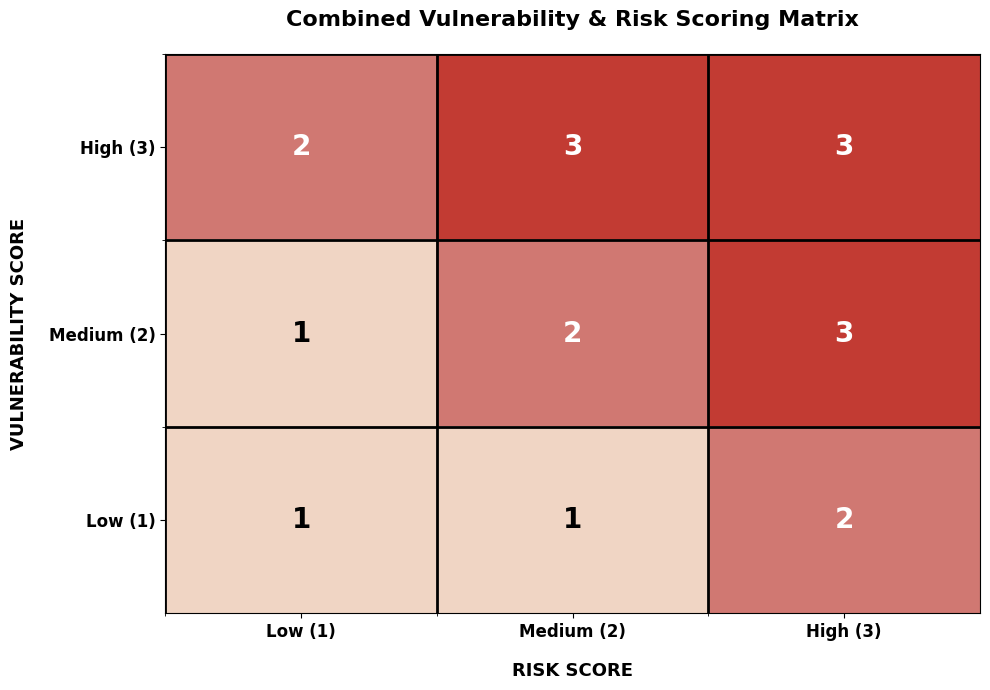

✓ Matrix visualization complete!

How to read this matrix:
- Row: Find your parcel's Vulnerability score (High/Medium/Low)
- Column: Find your parcel's Risk score (Low/Medium/High)
- Cell Value: The Combined Score (1=Low, 2=Medium, 3=High)


In [8]:
# Create the heatmap visualization
fig, ax = plt.subplots(figsize=(10, 7))

# Define colors: 1=light peach, 2=salmon, 3=strong red (official combined colors)
colors = ['#F0D5C4', '#D07872', '#C23B33']
cmap = ListedColormap(colors)

# Create the heatmap
im = ax.imshow(matrix_data, cmap=cmap, aspect='auto', vmin=1, vmax=3)

# Set row and column labels
vuln_labels = ['High (3)', 'Medium (2)', 'Low (1)']
risk_labels = ['Low (1)', 'Medium (2)', 'High (3)']

ax.set_xticks(np.arange(3))
ax.set_yticks(np.arange(3))
ax.set_xticklabels(risk_labels, fontsize=12, fontweight='bold')
ax.set_yticklabels(vuln_labels, fontsize=12, fontweight='bold')

# Add labels
ax.set_xlabel('RISK SCORE', fontsize=13, fontweight='bold', labelpad=15)
ax.set_ylabel('VULNERABILITY SCORE', fontsize=13, fontweight='bold', labelpad=15)

# Add text annotations in each cell
for i in range(3):
    for j in range(3):
        value = matrix_data[i, j]
        # Choose text color based on background
        text_color = 'white' if value >= 2 else 'black'
        text = ax.text(j, i, f'{int(value)}',
                      ha="center", va="center", color=text_color,
                      fontsize=20, fontweight='bold')

# Add title
plt.title('Combined Vulnerability & Risk Scoring Matrix',
          fontsize=16, fontweight='bold', pad=20)

# Add grid for clarity
ax.set_xticks(np.arange(3) - 0.5, minor=True)
ax.set_yticks(np.arange(3) - 0.5, minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=2)

plt.tight_layout()
plt.show()

print("✓ Matrix visualization complete!")
print("\nHow to read this matrix:")
print("- Row: Find your parcel's Vulnerability score (High/Medium/Low)")
print("- Column: Find your parcel's Risk score (Low/Medium/High)")
print("- Cell Value: The Combined Score (1=Low, 2=Medium, 3=High)")

## 5. Calculate Combined Scores

Now we apply the matrix to every parcel in our dataset. For each parcel, we:

1. Look up its Vulnerability score (from Class 4)
2. Look up its Risk score (from Class 7)
3. Use the matrix to find the Combined Score

This is a simple lookup operation that brings together all the analysis we've done.


In [9]:
# Apply the combined scoring matrix to all parcels
parcels['vuln_risk_combined'] = parcels.apply(
    lambda row: combined_matrix_dict.get((int(row['vulnerability']), int(row['risk'])), 0),
    axis=1
)

print(f"✓ Combined scores calculated!")
print(f"\nCombined Score Distribution:")
combined_counts = parcels['vuln_risk_combined'].value_counts().sort_index()
print(combined_counts)

# Calculate percentages
print(f"\nPercentages:")
for score in sorted(parcels['vuln_risk_combined'].unique()):
    if score == 0:
        continue
    count = (parcels['vuln_risk_combined'] == score).sum()
    pct = (count / len(parcels)) * 100
    score_name = {1: 'Low', 2: 'Medium', 3: 'High'}.get(score, 'Unknown')
    print(f"  {score_name} (Score {score}): {count:5d} parcels ({pct:5.1f}%)")


✓ Combined scores calculated!

Combined Score Distribution:
vuln_risk_combined
0    13849
1      761
2      799
3      669
Name: count, dtype: int64

Percentages:
  Low (Score 1):   761 parcels (  4.7%)
  Medium (Score 2):   799 parcels (  5.0%)
  High (Score 3):   669 parcels (  4.2%)


## 5.5. Detailed Cross-Tabulation Results Matrix

### Combined Vulnerability & Risk Results Analysis

This section presents a **detailed cross-tabulation matrix** showing the results of applying the combined scoring matrix to actual parcel data.

For each combination of Vulnerability and Risk scores, we analyze:
- **Number of Parcels**: How many properties fall into each vulnerability-risk combination
- **Parcel Value**: Total assessed value of land parcels
- **Building Value**: Total assessed value of structures
- **Combined Score**: The resulting priority score from our decision matrix

This reveals which vulnerability-risk combinations have the most properties and assets at stake, helping decision-makers prioritize investment and intervention.

**Color Coding:**
- Light peach background: Low combined score (1) = Lower priority
- Salmon background: Medium combined score (2) = Moderate priority  
- Red background: High combined score (3) = High priority


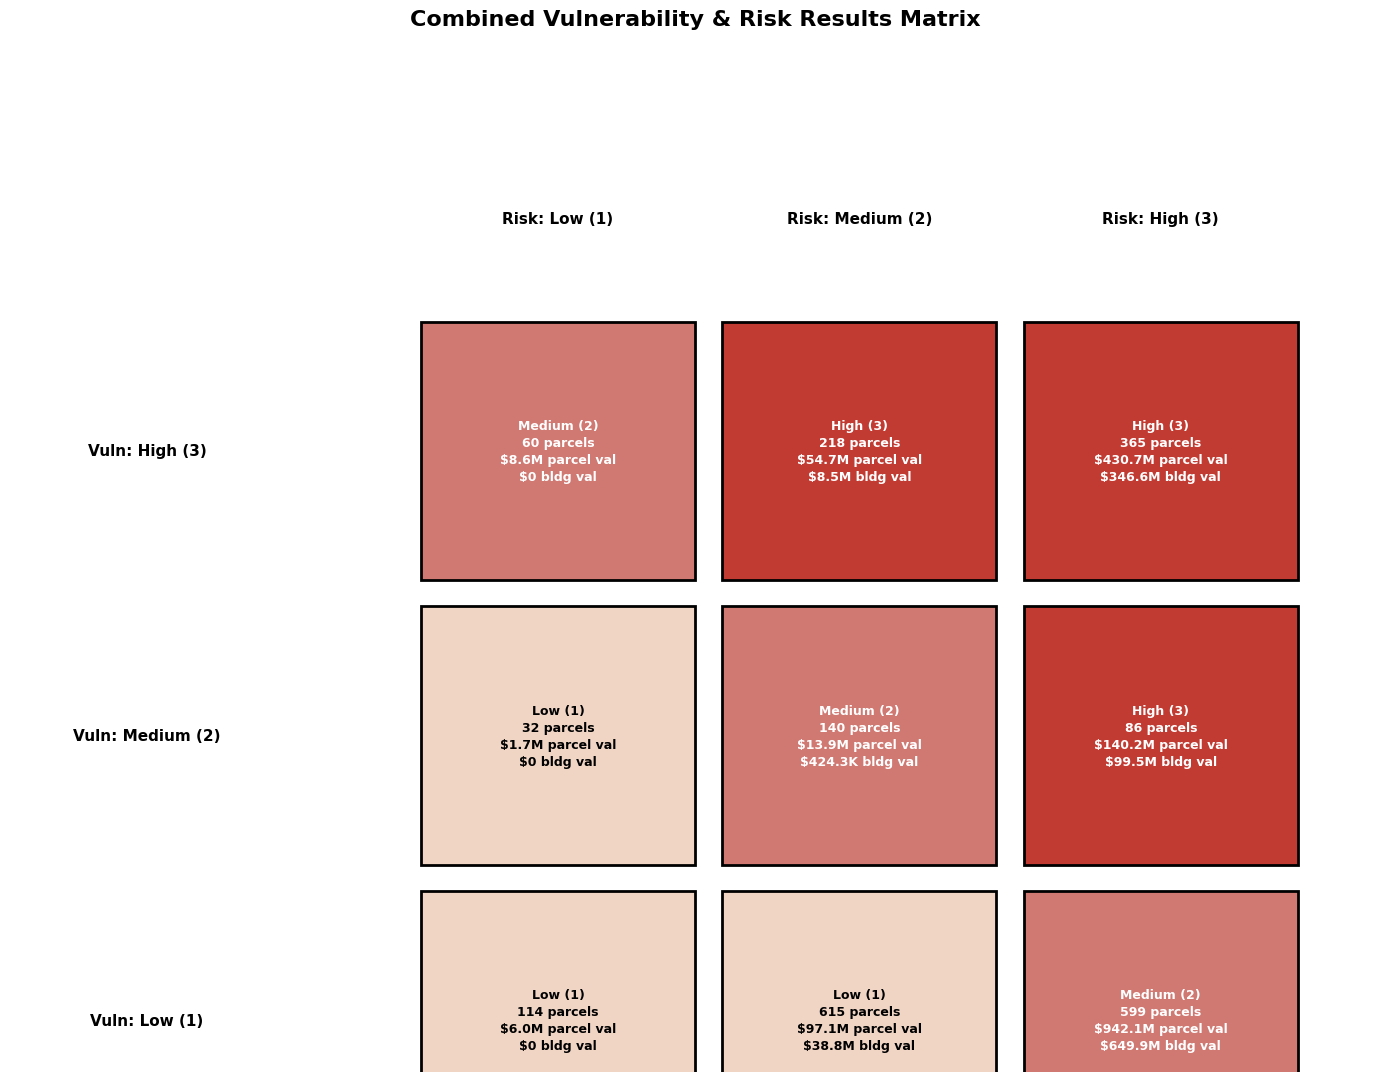

✓ Detailed results matrix visualization complete!

Matrix Summary:
Vuln:High + Risk:Low → Combined:Med |   60 parcels | Parcel:      $8.6M | Bldg:         $0
Vuln:High + Risk:Med → Combined:High |  218 parcels | Parcel:     $54.7M | Bldg:      $8.5M
Vuln:High + Risk:High → Combined:High |  365 parcels | Parcel:    $430.7M | Bldg:    $346.6M
Vuln:Med + Risk:Low → Combined:Low |   32 parcels | Parcel:      $1.7M | Bldg:         $0
Vuln:Med + Risk:Med → Combined:Med |  140 parcels | Parcel:     $13.9M | Bldg:    $424.3K
Vuln:Med + Risk:High → Combined:High |   86 parcels | Parcel:    $140.2M | Bldg:     $99.5M
Vuln:Low + Risk:Low → Combined:Low |  114 parcels | Parcel:      $6.0M | Bldg:         $0
Vuln:Low + Risk:Med → Combined:Low |  615 parcels | Parcel:     $97.1M | Bldg:     $38.8M
Vuln:Low + Risk:High → Combined:Med |  599 parcels | Parcel:    $942.1M | Bldg:    $649.9M


In [10]:
# Helper function to format currency
def format_currency(value):
    """Format numeric value as currency string."""
    if pd.isna(value) or value == 0:
        return "$0"
    abs_val = abs(value)
    if abs_val >= 1e6:
        return f"${value/1e6:.1f}M"
    elif abs_val >= 1e3:
        return f"${value/1e3:.1f}K"
    else:
        return f"${value:.0f}"

# Build the detailed results matrix
results_matrix_data = []

# Loop through all 9 combinations: vulnerability (high to low) x risk (low to high)
for vuln in [3, 2, 1]:  # Vulnerability: High (3) at top, Low (1) at bottom
    row_data = []
    for risk in [1, 2, 3]:  # Risk: Low (1) to High (3) left to right
        # Get parcels for this combination
        combo_parcels = parcels[(parcels['vulnerability'] == vuln) & (parcels['risk'] == risk)]
        
        # Count and sum values
        count = len(combo_parcels)
        
        # Sum parcel value (handle missing gracefully)
        parval_sum = 0
        if 'parcel_value' in combo_parcels.columns:
            parval_sum = combo_parcels['parcel_value'].fillna(0).sum()
        elif 'parval' in combo_parcels.columns:
            parval_sum = combo_parcels['parval'].fillna(0).sum()
        
        # Sum building/improvement value (handle missing gracefully)
        improvval_sum = 0
        if 'improvement_value' in combo_parcels.columns:
            improvval_sum = combo_parcels['improvement_value'].fillna(0).sum()
        elif 'improvval' in combo_parcels.columns:
            improvval_sum = combo_parcels['improvval'].fillna(0).sum()
        elif 'structure_value' in combo_parcels.columns:
            improvval_sum = combo_parcels['structure_value'].fillna(0).sum()
        
        # Get combined score from our matrix
        combined = combined_matrix_dict.get((vuln, risk), 0)
        
        row_data.append({
            'vuln': vuln,
            'risk': risk,
            'combined': combined,
            'count': count,
            'parval': parval_sum,
            'improvval': improvval_sum
        })
    results_matrix_data.append(row_data)

# Create the visualization
fig, ax = plt.subplots(figsize=(14, 11))

# Define colors for combined scores: 1=light peach, 2=salmon, 3=red (official combined colors)
color_map_results = {
    1: '#F0D5C4',  # Low = Light Peach
    2: '#D07872',  # Medium = Salmon
    3: '#C23B33',  # High = Red
}

# Cell dimensions and spacing
cell_width = 1.0
cell_height = 1.0
cell_spacing = 0.1

# Track position for text
y_base = 2.5  # Start from top

# Risk labels (columns)
risk_labels = ['Risk: Low (1)', 'Risk: Medium (2)', 'Risk: High (3)']

# Draw column headers (Risk scores)
for col_idx, risk_label in enumerate(risk_labels):
    x = col_idx * (cell_width + cell_spacing) + 1.5
    ax.text(x + cell_width/2, y_base + 0.3, risk_label,
           ha='center', va='center', fontsize=11, fontweight='bold')

# Draw row headers (Vulnerability scores) and cells
vuln_labels = ['Vuln: High (3)', 'Vuln: Medium (2)', 'Vuln: Low (1)']

for row_idx, (vuln_label, row_cells) in enumerate(zip(vuln_labels, results_matrix_data)):
    y = y_base - (row_idx + 1) * (cell_height + cell_spacing)
    
    # Row header (Vulnerability)
    ax.text(0.5, y + cell_height/2, vuln_label,
           ha='center', va='center', fontsize=11, fontweight='bold')
    
    # Draw cells for this row
    for col_idx, cell_data in enumerate(row_cells):
        x = col_idx * (cell_width + cell_spacing) + 1.5
        
        # Get background color based on combined score
        bg_color = color_map_results.get(cell_data['combined'], '#FFFFFF')
        
        # Determine text color (white on dark, black on light)
        text_color = 'white' if cell_data['combined'] >= 2 else 'black'
        
        # Draw cell rectangle
        from matplotlib.patches import Rectangle
        rect = Rectangle((x, y), cell_width, cell_height,
                         linewidth=2, edgecolor='black', facecolor=bg_color)
        ax.add_patch(rect)
        
        # Format cell text
        combined_name = {1: 'Low', 2: 'Medium', 3: 'High'}.get(cell_data['combined'], '?')
        
        cell_text = f"{combined_name} ({cell_data['combined']})\n"
        cell_text += f"{cell_data['count']} parcels\n"
        cell_text += f"{format_currency(cell_data['parval'])} parcel val\n"
        cell_text += f"{format_currency(cell_data['improvval'])} bldg val"
        
        # Add text to cell
        ax.text(x + cell_width/2, y + cell_height/2, cell_text,
               ha='center', va='center', fontsize=9, fontweight='bold',
               color=text_color, linespacing=1.4)

# Set axis limits and remove axes
ax.set_xlim(0, 5)
ax.set_ylim(-0.5, 3.5)
ax.axis('off')

# Title
plt.suptitle('Combined Vulnerability & Risk Results Matrix',
            fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

print("✓ Detailed results matrix visualization complete!")
print("\nMatrix Summary:")
print("="*100)
for row in results_matrix_data:
    for cell in row:
        if cell['count'] > 0:
            v_name = {1: 'Low', 2: 'Med', 3: 'High'}[cell['vuln']]
            r_name = {1: 'Low', 2: 'Med', 3: 'High'}[cell['risk']]
            c_name = {1: 'Low', 2: 'Med', 3: 'High'}[cell['combined']]
            print(f"Vuln:{v_name} + Risk:{r_name} → Combined:{c_name} | "
                  f"{cell['count']:4d} parcels | Parcel: {format_currency(cell['parval']):>10s} | "
                  f"Bldg: {format_currency(cell['improvval']):>10s}")
print("="*100)

## 5.6. Grand Summary: All 8 Scores Side-by-Side

### The Complete Analysis Journey

This culminating summary table brings together all 8 scores from the entire course, showing how each metric is distributed across your study area.

For each score (exposure, potential_impact, adaptive_capacity, vulnerability, probability, consequence, risk, and vuln_risk_combined), we show:
- **High Count**: Number of parcels with high score (3)
- **High %**: Percentage of parcels with high score
- **Medium Count**: Number of parcels with medium score (2)
- **Medium %**: Percentage of parcels with medium score
- **Low Count**: Number of parcels with low score (1)
- **Low %**: Percentage of parcels with low score
- **High Value**: Total monetary value of high-scoring parcels (to show asset concentration)

This table makes it easy to compare how different aspects of vulnerability and risk are distributed, and reveals which metrics are most concerning for your study area.


In [11]:
# Build comprehensive summary table of all 8 scores
score_fields = ['exposure', 'potential_impact', 'adaptive_capacity', 'vulnerability',
                'probability', 'consequence', 'risk', 'vuln_risk_combined']

# Determine which value field to use
value_field = None
for candidate in ['parcel_value', 'parval', 'improvement_value', 'improvval', 'structure_value', 'total_value']:
    if candidate in parcels.columns:
        value_field = candidate
        break

grand_summary = []

for field in score_fields:
    if field not in parcels.columns:
        continue
    
    # Count by score level
    high_count = (parcels[field] == 3).sum()
    high_pct = (high_count / len(parcels)) * 100 if len(parcels) > 0 else 0
    
    med_count = (parcels[field] == 2).sum()
    med_pct = (med_count / len(parcels)) * 100 if len(parcels) > 0 else 0
    
    low_count = (parcels[field] == 1).sum()
    low_pct = (low_count / len(parcels)) * 100 if len(parcels) > 0 else 0
    
    # Calculate total value for high-scoring parcels
    high_value = 0
    if value_field and high_count > 0:
        high_value = parcels[parcels[field] == 3][value_field].fillna(0).sum()
    
    grand_summary.append({
        'Score': field.replace('_', ' ').title(),
        'High Count': high_count,
        'High %': f"{high_pct:.1f}%",
        'Med Count': med_count,
        'Med %': f"{med_pct:.1f}%",
        'Low Count': low_count,
        'Low %': f"{low_pct:.1f}%",
        'High Value': format_currency(high_value) if value_field else 'N/A'
    })

# Create DataFrame and display
grand_summary_df = pd.DataFrame(grand_summary)

print("\n" + "="*160)
print("GRAND SUMMARY: ALL 8 ASSESSMENT SCORES")
print("="*160)
print(grand_summary_df.to_string(index=False))
print("="*160)

# Export to CSV for reference
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
csv_path = os.path.join(OUTPUT_DIR, 'grand_summary_all_scores.csv')
grand_summary_df.to_csv(csv_path, index=False)
print(f"\n✓ Grand summary exported to: {csv_path}")

# Display as nicely formatted table
display(grand_summary_df)


GRAND SUMMARY: ALL 8 ASSESSMENT SCORES
             Score  High Count High %  Med Count Med %  Low Count Low % High Value
          Exposure           0   0.0%          0  0.0%       2229 13.9%         $0
  Potential Impact         643   4.0%        258  1.6%       1328  8.3%    $494.1M
 Adaptive Capacity       13849  86.1%       2229 13.9%          0  0.0%   $4400.5M
     Vulnerability         643   4.0%        258  1.6%       1328  8.3%    $494.1M
       Probability        1425   8.9%        804  5.0%        226  1.4%   $1309.6M
       Consequence         715   4.4%        680  4.2%        834  5.2%   $1434.0M
              Risk        1050   6.5%        973  6.1%        206  1.3%   $1513.1M
Vuln Risk Combined         669   4.2%        799  5.0%        761  4.7%    $625.7M

✓ Grand summary exported to: ./outputs/grand_summary_all_scores.csv


,Score,High Count,High %,Med Count,Med %,Low Count,Low %,High Value
0,Exposure,0,0.0%,0,0.0%,2229,13.9%,$0
1,Potential Impact,643,4.0%,258,1.6%,1328,8.3%,$494.1M
2,Adaptive Capacity,13849,86.1%,2229,13.9%,0,0.0%,$4400.5M
3,Vulnerability,643,4.0%,258,1.6%,1328,8.3%,$494.1M
4,Probability,1425,8.9%,804,5.0%,226,1.4%,$1309.6M
5,Consequence,715,4.4%,680,4.2%,834,5.2%,$1434.0M
6,Risk,1050,6.5%,973,6.1%,206,1.3%,$1513.1M
7,Vuln Risk Combined,669,4.2%,799,5.0%,761,4.7%,$625.7M


## 6. Summary Statistics by Combined Score

Let's see how our results are distributed and what values are at risk.


In [12]:
# Create summary table of all 8 scores
score_fields = ['exposure', 'potential_impact', 'adaptive_capacity', 'vulnerability',
                'probability', 'consequence', 'risk', 'vuln_risk_combined']

summary_data = []

for field in score_fields:
    if field in parcels.columns:
        high = (parcels[field] == 3).sum()
        high_pct = (high / len(parcels)) * 100
        med = (parcels[field] == 2).sum()
        med_pct = (med / len(parcels)) * 100
        low = (parcels[field] == 1).sum()
        low_pct = (low / len(parcels)) * 100

        summary_data.append({
            'Score': field.replace('_', ' ').title(),
            'High (3)': f"{high} ({high_pct:.1f}%)",
            'Medium (2)': f"{med} ({med_pct:.1f}%)",
            'Low (1)': f"{low} ({low_pct:.1f}%)",
        })

summary_df = pd.DataFrame(summary_data)
print("ASSESSMENT RESULTS ACROSS ALL CLASSES:")
print("=" * 120)
print(summary_df.to_string(index=False))
print("=" * 120)


ASSESSMENT RESULTS ACROSS ALL CLASSES:
             Score      High (3)   Medium (2)      Low (1)
          Exposure      0 (0.0%)     0 (0.0%) 2229 (13.9%)
  Potential Impact    643 (4.0%)   258 (1.6%)  1328 (8.3%)
 Adaptive Capacity 13849 (86.1%) 2229 (13.9%)     0 (0.0%)
     Vulnerability    643 (4.0%)   258 (1.6%)  1328 (8.3%)
       Probability   1425 (8.9%)   804 (5.0%)   226 (1.4%)
       Consequence    715 (4.4%)   680 (4.2%)   834 (5.2%)
              Risk   1050 (6.5%)   973 (6.1%)   206 (1.3%)
Vuln Risk Combined    669 (4.2%)   799 (5.0%)   761 (4.7%)


## 7. Comprehensive Multi-Panel Visualization

This figure shows all 8 scores in one place, so you can see how the assessment evolved from Exposure → Combined Score.


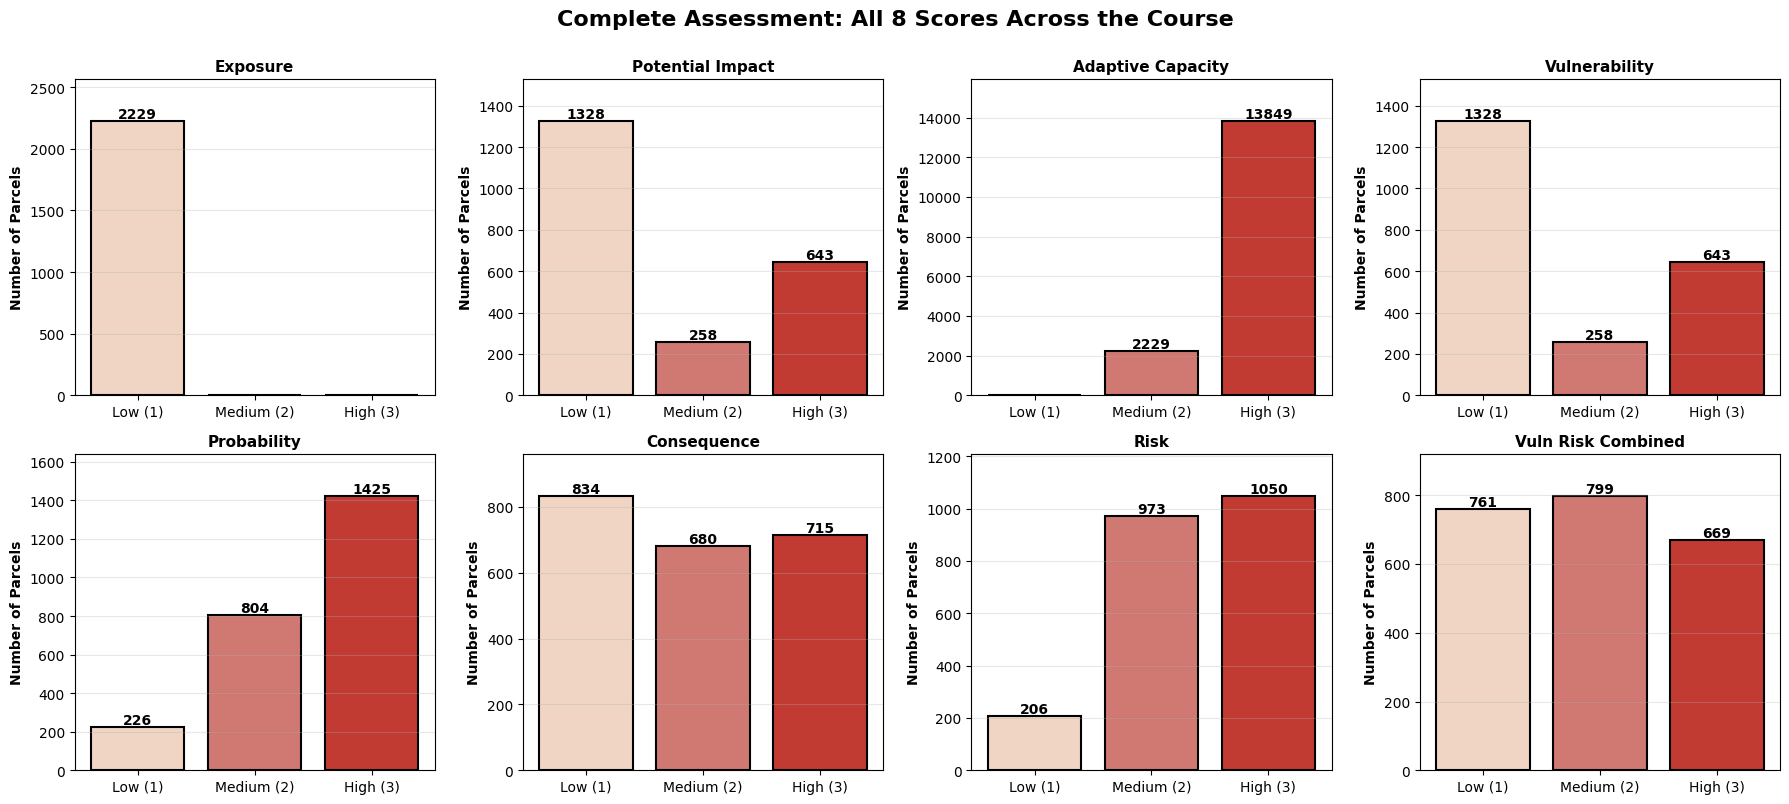

✓ Multi-panel visualization complete!


In [13]:
# Create a multi-panel figure showing all 8 scores
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

score_fields = ['exposure', 'potential_impact', 'adaptive_capacity', 'vulnerability',
                'probability', 'consequence', 'risk', 'vuln_risk_combined']

# Color scheme: Low=Peach, Medium=Salmon, High=Red (official combined colors)
colors_map = {1: '#F0D5C4', 2: '#D07872', 3: '#C23B33'}

for idx, (ax, field) in enumerate(zip(axes, score_fields)):
    if field in parcels.columns:
        # Get value counts
        counts = parcels[field].value_counts().sort_index()

        # Prepare data for bar chart
        score_names = ['Low (1)', 'Medium (2)', 'High (3)']
        values = [counts.get(i, 0) for i in [1, 2, 3]]
        bar_colors = [colors_map.get(i, 'gray') for i in [1, 2, 3]]

        # Create bar chart
        bars = ax.bar(score_names, values, color=bar_colors, edgecolor='black', linewidth=1.5)

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height)}',
                       ha='center', va='bottom', fontweight='bold')

        # Labels and title
        ax.set_ylabel('Number of Parcels', fontweight='bold')
        title = field.replace('_', ' ').title()
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_ylim(0, max(values) * 1.15)
        ax.grid(axis='y', alpha=0.3)

plt.suptitle('Complete Assessment: All 8 Scores Across the Course',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✓ Multi-panel visualization complete!")

In [14]:
# Create cross-tabulation: Vulnerability vs Risk vs Combined
crosstab_data = []

for vuln in sorted(parcels['vulnerability'].unique()):
    for risk in sorted(parcels['risk'].unique()):
        subset = parcels[(parcels['vulnerability'] == vuln) & (parcels['risk'] == risk)]
        if len(subset) > 0:
            combined = subset['vuln_risk_combined'].iloc[0]
            crosstab_data.append({
                'Vulnerability': int(vuln),
                'Risk': int(risk),
                'Combined Score': int(combined),
                'Count': len(subset),
                'Percentage': f"{(len(subset)/len(parcels)*100):.1f}%"
            })

crosstab_df = pd.DataFrame(crosstab_data)
print("\nCross-Tabulation: Vulnerability × Risk → Combined Score")
print("=" * 90)
print(crosstab_df.to_string(index=False))
print("=" * 90)



Cross-Tabulation: Vulnerability × Risk → Combined Score
 Vulnerability  Risk  Combined Score  Count Percentage
             0     0               0  13849      86.1%
             1     1               1    114       0.7%
             1     2               1    615       3.8%
             1     3               2    599       3.7%
             2     1               1     32       0.2%
             2     2               2    140       0.9%
             2     3               3     86       0.5%
             3     1               2     60       0.4%
             3     2               3    218       1.4%
             3     3               3    365       2.3%


## 8. Map the Final Combined Score

We'll create a beautiful map showing the Combined Score across the study area. This is the final, most important map of the course.


In [15]:
# Load flood zones for reference (if available)
try:
    flood_zones = gpd.read_file(gpkg_path, layer='flood_zones')
    print(f"✓ Loaded {len(flood_zones)} flood zone features")
except:
    print("⚠ Flood zones layer not found")
    flood_zones = None


✓ Loaded 233 flood zone features


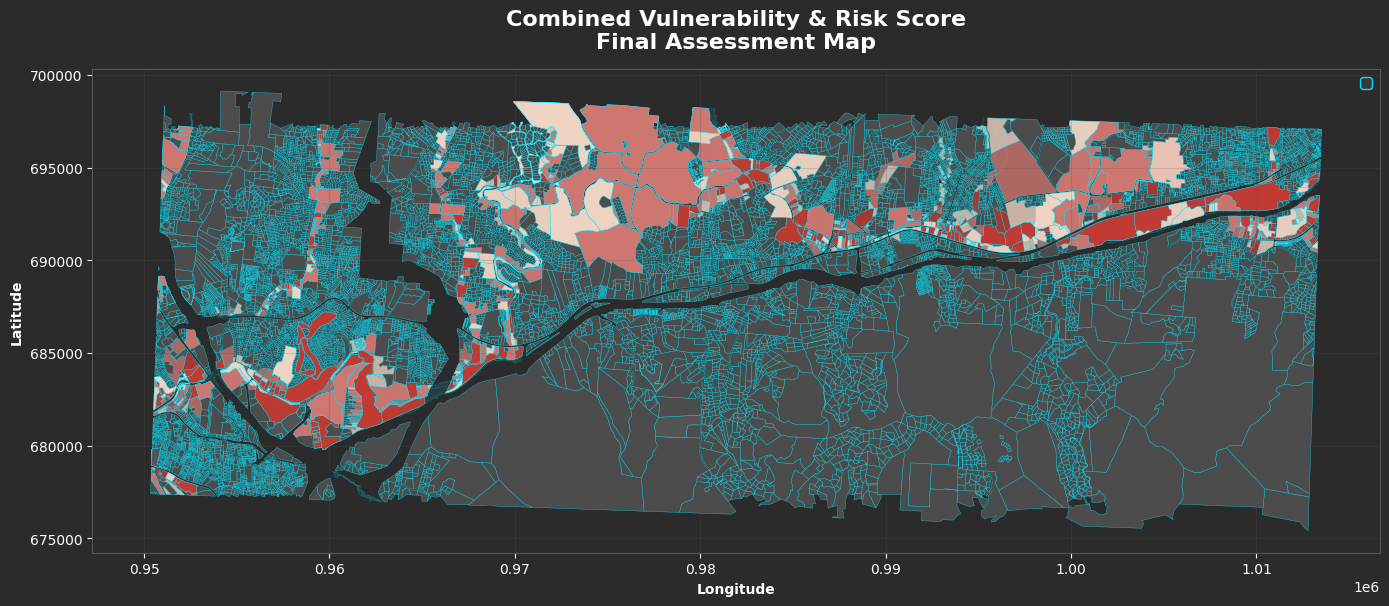

✓ Final combined score map created!


In [16]:
# Create the final combined score map with dark theme
fig, ax = plt.subplots(figsize=(14, 10), facecolor='#2b2b2b')
ax.set_facecolor('#2b2b2b')

# Color scheme for combined scores - official combined palette
color_map = {
    1: '#F0D5C4',  # Low = Light Peach
    2: '#D07872',  # Medium = Salmon
    3: '#C23B33',  # High = Red
    0: '#555555'   # No data = Dark gray
}

# Plot flood zones as reference (light gray background)
if flood_zones is not None:
    flood_zones.plot(ax=ax, alpha=0.1, edgecolor='#00e5ff', linewidth=0.5, color='#00e5ff')

# Plot parcels colored by combined score
for score in sorted(parcels['vuln_risk_combined'].unique(), reverse=True):
    subset = parcels[parcels['vuln_risk_combined'] == score]
    score_name = {1: 'Low', 2: 'Medium', 3: 'High', 0: 'No Data'}.get(score, 'Unknown')
    subset.plot(ax=ax, alpha=0.8, edgecolor='#00e5ff', linewidth=0.3,
               color=color_map.get(score, '#555555'),
               label=f'{score_name} ({score}): {len(subset)} parcels')

# Format map with dark theme
ax.set_title('Combined Vulnerability & Risk Score\nFinal Assessment Map',
            fontsize=16, fontweight='bold', pad=15, color='white')
ax.set_xlabel('Longitude', fontweight='bold', color='white')
ax.set_ylabel('Latitude', fontweight='bold', color='white')
ax.legend(loc='upper right', fontsize=11, framealpha=0.95, 
          facecolor='#3a3a3a', edgecolor='#00e5ff', labelcolor='white')
ax.grid(True, alpha=0.2, color='#555555')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('#555555')

plt.tight_layout()
plt.show()

print("✓ Final combined score map created!")

✓ Buildings loaded: 22222 features
✓ Flood zones loaded: 233 features
  Categories: {'100-year': 109, '500-year': 108, 'Floodway': 16}


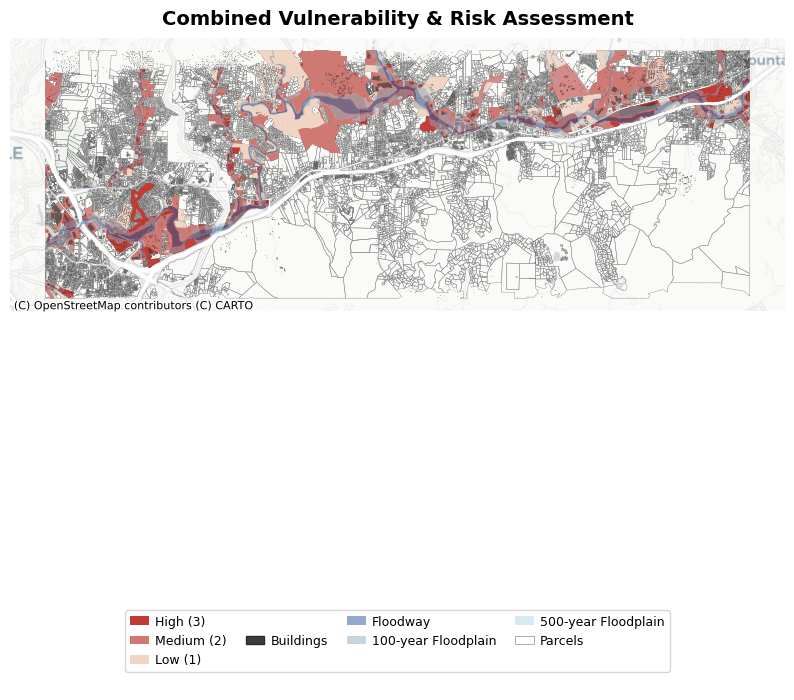

✓ Map exported to: ./outputs/combined_score_map.png


In [17]:
import contextily as ctx
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

# Reproject to Web Mercator for basemap tiles
parcels_wm = parcels.to_crs(epsg=3857)

# Create figure with map panel + legend panel below
fig = plt.figure(figsize=(10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios=[10, 1.2], hspace=0.02)
ax = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

# Layer 1 (bottom): All parcels - no fill, thin grey borders
parcels_wm.plot(ax=ax, facecolor='none', edgecolor='#888888', linewidth=0.3)

# Layer 2: Combined score layer - score 0 NOT plotted
combined_colors = {1: '#F0D5C4', 2: '#D07872', 3: '#C23B33'}
for score in [3, 2, 1]:  # Plot high scores first so low scores render on top
    subset = parcels_wm[parcels_wm['vuln_risk_combined'] == score]
    if len(subset) > 0:
        subset.plot(ax=ax, facecolor=combined_colors[score], edgecolor='none', alpha=0.85)

# Layer 3: Buildings
try:
    buildings_layer = gpd.read_file(CLASS0_GPKG, layer='buildings')
    buildings_wm = buildings_layer.to_crs(epsg=3857)
    buildings_wm.plot(ax=ax, facecolor='#3D3D3D', edgecolor='#2a2a2a', linewidth=0.1, alpha=0.7)
    print(f"✓ Buildings loaded: {len(buildings_layer)} features")
except Exception as e:
    print(f"⚠ Could not load buildings: {e}")

# Layer 4: Flood zones with transparency (all three categories)
try:
    flood_zones_full = gpd.read_file(CLASS0_GPKG, layer='flood_zones')
    flood_wm = flood_zones_full.to_crs(epsg=3857)
    flood_colors = {'Floodway': '#2B5797', '100-year': '#8FABBE', '500-year': '#B4D4E7'}
    for flood_type in ['500-year', '100-year', 'Floodway']:
        flood_subset = flood_wm[flood_wm['flood_category'] == flood_type]
        if len(flood_subset) > 0:
            flood_subset.plot(ax=ax, facecolor=flood_colors.get(flood_type, '#B4D4E7'),
                            edgecolor='none', alpha=0.5)
    print(f"✓ Flood zones loaded: {len(flood_zones_full)} features")
    print(f"  Categories: {flood_zones_full['flood_category'].value_counts().to_dict()}")
except Exception as e:
    print(f"⚠ Could not load flood zones: {e}")

# Add CartoDB Positron (light) basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto')

# Style the map panel
ax.set_axis_off()
ax.set_title('Combined Vulnerability & Risk Assessment', fontsize=14, fontweight='bold', pad=10)

# Build legend in bottom panel
ax_legend.set_axis_off()
legend_elements = [
    Patch(facecolor='#C23B33', edgecolor='none', label='High (3)'),
    Patch(facecolor='#D07872', edgecolor='none', label='Medium (2)'),
    Patch(facecolor='#F0D5C4', edgecolor='none', label='Low (1)'),
    Patch(facecolor='none', edgecolor='none', label=''),  # spacer
    Patch(facecolor='#3D3D3D', edgecolor='#2a2a2a', label='Buildings'),
    Patch(facecolor='#2B5797', edgecolor='none', alpha=0.5, label='Floodway'),
    Patch(facecolor='#8FABBE', edgecolor='none', alpha=0.5, label='100-year Floodplain'),
    Patch(facecolor='#B4D4E7', edgecolor='none', alpha=0.5, label='500-year Floodplain'),
    Patch(facecolor='none', edgecolor='#888888', linewidth=0.5, label='Parcels'),
]
ax_legend.legend(handles=legend_elements, loc='center', ncol=4, fontsize=9,
                frameon=True, facecolor='white', edgecolor='#cccccc',
                handlelength=1.5, handletextpad=0.5, columnspacing=1.5)

# Export
# Ensure OUTPUT_DIR is defined and created
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
png_path = os.path.join(OUTPUT_DIR, 'combined_score_map.png')
plt.savefig(png_path, dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print(f"✓ Map exported to: {png_path}")

## Step 8.5: Export Combined Score Map as PNG

Now we'll create a publication-quality PNG map that combines all layers in the proper order with dark styling. This map shows the final combined vulnerability and risk assessment with all supporting layers (buildings, flood zones, and parcels) in a single exportable image.

## 9. Asset Values at Risk

Now let's calculate which areas have the most value at risk based on the combined score.


In [18]:
# Check for value fields
value_fields = [col for col in parcels.columns if 'value' in col.lower()]
print(f"Available value fields: {value_fields}")

# If structure_value field exists, analyze by combined score
if 'structure_value' in parcels.columns or len(value_fields) > 0:
    value_col = value_fields[0] if value_fields else None

    if value_col:
        print(f"\nUsing field: {value_col}")
        print(f"\nTotal Assets at Risk by Combined Score:")
        print("=" * 70)

        for score in sorted(parcels['vuln_risk_combined'].unique()):
            if score == 0:
                continue
            subset = parcels[parcels['vuln_risk_combined'] == score]
            count = len(subset)
            total_value = subset[value_col].sum()
            avg_value = subset[value_col].mean()
            score_name = {1: 'Low', 2: 'Medium', 3: 'High'}.get(score, 'Unknown')

            print(f"{score_name} ({score}): {count:5d} parcels | "
                  f"Total Value: ${total_value:>15,.0f} | Avg: ${avg_value:>12,.0f}")

        print("=" * 70)
else:
    print("⚠ No value field found. Skipping asset analysis.")


Available value fields: []
⚠ No value field found. Skipping asset analysis.


## 10. Complete Field Reference Guide

Here's what every field means and which class created it:


In [19]:
# Create field reference table
field_ref = pd.DataFrame([
    {
        'Field': 'exposure',
        'Class': 'Class 1',
        'Score Range': '1-3',
        'Description': 'Is the parcel in the 100-year flood zone? (1=No, 3=Yes)'
    },
    {
        'Field': 'potential_impact',
        'Class': 'Class 2',
        'Score Range': '1-3',
        'Description': 'What is exposed? (1=Low impact, 2=Medium, 3=High impact)'
    },
    {
        'Field': 'adaptive_capacity',
        'Class': 'Class 3',
        'Score Range': '1-3',
        'Description': 'How prepared are we? Year built vs building codes (1=Well prepared, 3=Poorly prepared)'
    },
    {
        'Field': 'vulnerability',
        'Class': 'Class 4',
        'Score Range': '1-3',
        'Description': 'Combined Potential Impact × Adaptive Capacity (1=Low, 3=High)'
    },
    {
        'Field': 'probability',
        'Class': 'Class 5',
        'Score Range': '1-3',
        'Description': 'Flood probability by zone type (1=Low, 3=High)'
    },
    {
        'Field': 'consequence',
        'Class': 'Class 6',
        'Score Range': '1-3',
        'Description': 'Potential consequence by structure value (1=Low, 3=High)'
    },
    {
        'Field': 'risk',
        'Class': 'Class 7',
        'Score Range': '1-3',
        'Description': 'Combined Probability × Consequence (1=Low, 3=High)'
    },
    {
        'Field': 'vuln_risk_combined',
        'Class': 'Class 8',
        'Score Range': '1-3',
        'Description': 'Combined Vulnerability × Risk using matrix (1=Low, 3=High)'
    },
])

print("COMPLETE FIELD REFERENCE GUIDE")
print("=" * 130)
for idx, row in field_ref.iterrows():
    print(f"\n{row['Field'].upper()}")
    print(f"  Created in: {row['Class']}")
    print(f"  Score Range: {row['Score Range']}")
    print(f"  Description: {row['Description']}")
print("\n" + "=" * 130)


COMPLETE FIELD REFERENCE GUIDE

EXPOSURE
  Created in: Class 1
  Score Range: 1-3
  Description: Is the parcel in the 100-year flood zone? (1=No, 3=Yes)

POTENTIAL_IMPACT
  Created in: Class 2
  Score Range: 1-3
  Description: What is exposed? (1=Low impact, 2=Medium, 3=High impact)

ADAPTIVE_CAPACITY
  Created in: Class 3
  Score Range: 1-3
  Description: How prepared are we? Year built vs building codes (1=Well prepared, 3=Poorly prepared)

VULNERABILITY
  Created in: Class 4
  Score Range: 1-3
  Description: Combined Potential Impact × Adaptive Capacity (1=Low, 3=High)

PROBABILITY
  Created in: Class 5
  Score Range: 1-3
  Description: Flood probability by zone type (1=Low, 3=High)

CONSEQUENCE
  Created in: Class 6
  Score Range: 1-3
  Description: Potential consequence by structure value (1=Low, 3=High)

RISK
  Created in: Class 7
  Score Range: 1-3
  Description: Combined Probability × Consequence (1=Low, 3=High)

VULN_RISK_COMBINED
  Created in: Class 8
  Score Range: 1-3
  Des

## 11. Save Updated Data

We save the complete results back to the GeoPackage, including all 8 scores for future reference.


In [20]:
try:
    import fiona
    import sqlite3
    
    # Save parcels layer first (creates new GeoPackage)
    parcels.to_file(OUTPUT_GPKG, layer='parcels', driver='GPKG', mode='w')
    print(f"✓ Saved parcels layer with vuln_risk_combined ({len(parcels)} features)")
    
    # Copy forward all other layers from the input GeoPackage
    if os.path.exists(INPUT_GPKG):
        input_layers = fiona.listlayers(INPUT_GPKG)
        for layer_name in input_layers:
            if layer_name == 'parcels':
                continue  # Already saved updated version
            try:
                layer_data = gpd.read_file(INPUT_GPKG, layer=layer_name)
                layer_data.to_file(OUTPUT_GPKG, layer=layer_name, driver='GPKG', mode='a')
                print(f"✓ Copied layer: {layer_name} ({len(layer_data)} features)")
            except Exception as e:
                print(f"  Note: Could not copy layer '{layer_name}' as spatial: {e}")
        
        # Also copy any non-spatial tables (like 'summary') via sqlite3
        try:
            conn_in = sqlite3.connect(INPUT_GPKG)
            conn_out = sqlite3.connect(OUTPUT_GPKG)
            cursor = conn_in.cursor()
            # Get all tables that aren't in fiona's layer list and aren't system tables
            cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
            all_tables = [row[0] for row in cursor.fetchall()]
            system_tables = ['gpkg_contents', 'gpkg_geometry_columns', 'gpkg_spatial_ref_sys',
                            'gpkg_ogr_contents', 'gpkg_tile_matrix', 'gpkg_tile_matrix_set',
                            'sqlite_sequence', 'gpkg_extensions', 'gpkg_metadata',
                            'gpkg_metadata_reference']
            for table in all_tables:
                if table in system_tables or table in input_layers or table.startswith('rtree_') or table.startswith('trigger_'):
                    continue
                try:
                    df = pd.read_sql(f'SELECT * FROM "{table}"', conn_in)
                    if len(df) > 0:
                        df.to_sql(table, conn_out, if_exists='replace', index=False)
                        print(f"✓ Copied non-spatial table: {table} ({len(df)} rows)")
                except Exception:
                    pass
            conn_in.close()
            conn_out.close()
        except Exception:
            pass
    
    # Also ensure base layers from Class 0 are included (flood_zones, buildings, study_area)
    # These may not be in INPUT_GPKG if earlier classes didn't carry them forward
    if os.path.exists(CLASS0_GPKG):
        try:
            import fiona as _fiona
            # Get layers already written to output
            output_layers = _fiona.listlayers(OUTPUT_GPKG)
            # Get layers available in Class 0
            class0_layers = _fiona.listlayers(CLASS0_GPKG)
            # Copy any missing layers
            for layer_name in class0_layers:
                if layer_name not in output_layers:
                    try:
                        layer_data = gpd.read_file(CLASS0_GPKG, layer=layer_name)
                        layer_data.to_file(OUTPUT_GPKG, layer=layer_name, driver='GPKG', mode='a')
                        print(f"✓ Added base layer from Class 0: {layer_name} ({len(layer_data)} features)")
                    except Exception as e:
                        print(f"  Note: Could not copy base layer '{layer_name}': {e}")
        except Exception:
            pass
    
    print(f"\n✓ All data saved to: {OUTPUT_GPKG}")
except Exception as e:
    print(f"✗ Error saving to GeoPackage: {e}")
    print("\nAlternative: Save to a new GeoPackage file")
    alt_path = os.path.join(DATA_DIR, 'class_8_final_backup.gpkg')
    parcels.to_file(alt_path, layer='parcels', driver='GPKG')
    print(f"✓ Saved to: {alt_path}")

✓ Saved parcels layer with vuln_risk_combined (16078 features)
✓ Copied layer: flood_zones_100yr (250 features)
✓ Copied layer: study_area (1 features)
✓ Copied layer: flood_zones (233 features)
✓ Copied layer: buildings (22222 features)

✓ All data saved to: ./data/class_8_final.gpkg


In [21]:
# Export summary statistics to CSV for easy reference
summary_export = parcels[['objectid', 'vulnerability', 'risk', 'vuln_risk_combined']].copy()

# Add any other useful columns
for col in ['parcel_id', 'address', 'structure_value']:
    if col in parcels.columns:
        summary_export[col] = parcels[col]

# Sort by combined score (high to low)
summary_export = summary_export.sort_values('vuln_risk_combined', ascending=False)

csv_path = os.path.join(OUTPUT_DIR, 'combined_scores_summary.csv')
summary_export.to_csv(csv_path, index=False)
print(f"✓ Exported summary to: {csv_path}")
print(f"\nFirst 20 parcels (sorted by combined score, highest first):")
print(summary_export.head(20).to_string(index=False))


✓ Exported summary to: ./outputs/combined_scores_summary.csv

First 20 parcels (sorted by combined score, highest first):
 objectid  vulnerability  risk  vuln_risk_combined
 24213621              3     2                   3
 24227114              3     3                   3
 24223594              3     3                   3
 24302693              3     3                   3
 24274947              3     3                   3
 24313750              3     3                   3
 24219860              3     3                   3
 24323908              3     3                   3
 24216473              3     3                   3
 24247345              3     3                   3
 24255162              2     3                   3
 24329940              3     3                   3
 24215801              3     3                   3
 24202928              3     3                   3
 24238964              3     3                   3
 24276575              3     3                   3
 24304092  

## 12. 🎓 Course Summary & Reflection

### The Journey

You have completed a comprehensive **GIS Vulnerability & Risk Assessment**. Here's what you've accomplished:

#### Foundation Concepts (Classes 1-3)
- **Class 1 - Exposure**: Identified what's in the hazard zone
- **Class 2 - Potential Impact**: Determined what could be damaged
- **Class 3 - Adaptive Capacity**: Assessed community preparedness

#### Vulnerability Assessment (Class 4)
- Combined Impact + Capacity into a single **Vulnerability Score**
- Created the first strategic assessment metric
- Identified areas most exposed to harm

#### Risk Assessment (Classes 5-7)
- **Class 5 - Probability**: Assessed flood likelihood
- **Class 6 - Consequence**: Assessed potential damage severity
- **Class 7 - Risk**: Combined Probability + Consequence
- Created a second strategic assessment metric based on hazard probability

#### Final Integration (Class 8 - TODAY)
- Combined Vulnerability + Risk into a final assessment
- Created a decision matrix that brings all analysis together
- Produced publication-quality maps and statistics
- Completed a full lifecycle vulnerability and risk assessment

### Key Insights

Your analysis answers critical questions:

1. **Where are we most vulnerable?** (Vulnerability Score)
2. **Where is the hazard most likely to strike?** (Risk Score)
3. **Where do both vulnerability AND risk converge?** (Combined Score)

The **Combined Score highlights areas where**:
- Communities are vulnerable (exposed + unprepared)
- **AND** hazards are likely (probable + consequential)

These are your **priority areas for mitigation and adaptation**.

### Next Steps: Putting Results to Work

Now that you have these maps and scores, you can:

1. **Communicate Findings**
   - Present maps to city council or community groups
   - Create stakeholder reports highlighting priority areas
   - Use visualizations to build political will for action

2. **Guide Planning & Investment**
   - Prioritize mitigation projects in high-priority areas
   - Target flood insurance programs
   - Plan infrastructure improvements in vulnerable neighborhoods
   - Direct adaptation funding to highest-need areas

3. **Develop Adaptation Strategies**
   - For High Combined Score areas: Major investments needed
     - Structural improvements (elevation, barriers)
     - Buyout/relocation programs
     - Major infrastructure upgrades
   - For Medium Combined Score areas: Moderate investments
     - Property-level improvements
     - Warning systems
     - Community preparation
   - For Low Combined Score areas: Monitoring & maintenance
     - Standard maintenance
     - Periodic reassessment

4. **Monitor & Update**
   - Re-run analysis every 5-10 years
   - Track as communities adapt and rebuild
   - Evaluate success of mitigation measures
   - Adjust strategies as climate and conditions change

### Technical Skills You've Learned

- Working with geospatial data in Python (GeoPandas)
- Combining data from multiple sources
- Creating decision matrices for complex analysis
- Building scoring systems
- Creating publication-quality visualizations
- Documenting methodology for reproducibility

### Tools & Software

Throughout this course, you learned GIS concepts that are transferable to:
- **QGIS**: Open-source GIS platform (expressions provided in each class)
- **ArcGIS Pro**: Industry-standard GIS software (Python expressions provided)
- **Python/GeoPandas**: Reproducible, scriptable analysis
- Any other GIS platform: Logic is the same

### Final Thoughts

You've completed a professional-grade vulnerability and risk assessment. This is real work done by:
- City planning departments
- Emergency management agencies
- Climate adaptation consultants
- Insurance companies
- Insurance and climate organizations

Congratulations on building these important analytical skills!

---

**Questions for Reflection:**
- Which areas emerged as highest priority? Why?
- What surprised you in the results?
- How might you communicate these findings to different audiences?
- What additional data would strengthen your analysis?
- How might these results change in 50 years with climate change?


## Color Reference for GIS Symbology

Use these hex color values when styling your combined score layer in QGIS or ArcGIS Pro:

| Score | Label | Hex Code | RGB |
|-------|-------|----------|-----|
| 1 | Low | `#F0D5C4` | 240, 213, 196 |
| 2 | Medium | `#D07872` | 208, 120, 114 |
| 3 | High | `#C23B33` | 194, 59, 51 |

**How to apply in QGIS:**
1. Right-click your layer → Properties → Symbology
2. Choose "Categorized" from the dropdown
3. Set Column to `vuln_risk_combined`
4. Click "Classify"
5. Double-click each symbol to change its color using the hex values above

**How to apply in ArcGIS Pro:**
1. Right-click your layer → Symbology
2. Choose "Unique Values"
3. Set Field 1 to `vuln_risk_combined`
4. Click "Add all values"
5. Double-click each symbol to change its color using the hex values above

**Pre-made symbology files** are also available in the `symbology/` folder:
- `combined_vuln_risk_symbology.qml` — Load in QGIS via Style → Load Style
- `combined_vuln_risk_symbology.lyrx` — Import in ArcGIS Pro via Symbology → Import


## 13. Using Results in QGIS & ArcGIS Pro

The analysis you did in Python can be replicated in other GIS software. Here's how:

### QGIS: Field Calculator Expression

To create the combined score field in QGIS:

1. Open the parcels layer in QGIS
2. Enter Edit Mode (pencil icon)
3. Open the Attribute Table
4. Create a new field called `vuln_risk_combined` (type: Integer)
5. Use the Field Calculator (click the calculator icon in the header)
6. Enter this expression:

```qgis
CASE
  WHEN "vulnerability" = 3 AND "risk" = 1 THEN 2
  WHEN "vulnerability" = 3 AND "risk" = 2 THEN 3
  WHEN "vulnerability" = 3 AND "risk" = 3 THEN 3
  WHEN "vulnerability" = 2 AND "risk" = 1 THEN 1
  WHEN "vulnerability" = 2 AND "risk" = 2 THEN 2
  WHEN "vulnerability" = 2 AND "risk" = 3 THEN 3
  WHEN "vulnerability" = 1 AND "risk" = 1 THEN 1
  WHEN "vulnerability" = 1 AND "risk" = 2 THEN 1
  WHEN "vulnerability" = 1 AND "risk" = 3 THEN 2
  ELSE 0
END
```

7. Click OK and save the layer

### ArcGIS Pro: Python Expression

In ArcGIS Pro's Field Calculator:

1. Create a new Integer field called `vuln_risk_combined`
2. Switch to the Python tab in Field Calculator
3. Use this code block:

```python
def calc_combined(vulnerability, risk):
    matrix = {
        (3,1): 2, (3,2): 3, (3,3): 3,
        (2,1): 1, (2,2): 2, (2,3): 3,
        (1,1): 1, (1,2): 1, (1,3): 2
    }
    return matrix.get((vulnerability, risk), 0)
```

Then use the expression: `calc_combined(!vulnerability!, !risk!)`

### ArcGIS Pro: ArcPy Script Tool (Alternative)

If you want a more robust solution in ArcGIS Pro:

```python
import arcpy
fc = arcpy.GetParameterAsText(0)  # Input feature class

matrix = {
    (3,1): 2, (3,2): 3, (3,3): 3,
    (2,1): 1, (2,2): 2, (2,3): 3,
    (1,1): 1, (1,2): 1, (1,3): 2
}

arcpy.AddField_management(fc, "vuln_risk_combined", "SHORT")

with arcpy.da.UpdateCursor(fc, ["vulnerability", "risk", "vuln_risk_combined"]) as cursor:
    for row in cursor:
        v, r = int(row[0]), int(row[1])
        row[2] = matrix.get((v, r), 0)
        cursor.updateRow(row)

arcpy.SetParameterAsText(1, "Complete")
```


## 14. Final Congratulations

🎉 **You have successfully completed the GIS Vulnerability & Risk Assessment Course!**

You have:
- ✅ Analyzed geospatial data with Python and GeoPandas
- ✅ Applied decision matrices to complex problems
- ✅ Created vulnerability scores from multiple factors
- ✅ Assessed risk through probability and consequence
- ✅ Combined assessments into actionable priorities
- ✅ Visualized results with publication-quality maps
- ✅ Documented methodology for reproducibility

Your combined score map is now ready to:
- Present to decision-makers
- Guide adaptation planning
- Support funding requests
- Inform emergency preparedness
- Drive community resilience

Thank you for completing this course. These skills are valuable for climate adaptation, emergency management, urban planning, and environmental protection.

**Keep learning. Keep mapping. Keep making a difference.**

---

*For questions or to use this data further, contact your instructor or GIS coordinator.*
